# Assignment 4: Training Transformers in PyTorch

*Author:* Thomas Adler

*Copyright statement:* This  material,  no  matter  whether  in  printed  or  electronic  form,  may  be  used  for  personal  and non-commercial educational use only.  Any reproduction of this manuscript, no matter whether as a whole or in parts, no matter whether in printed or in electronic form, requires explicit prior acceptance of the authors.

In this assignment we will implement and train a small transformer model and compare it to the LSTM in the previous assignment. 

## Exercise 1: Causal Self-Attention

Write a class named `CausalSelfAttention` that derives from `nn.Module` and whose `__init__` method takes (apart from the trivial `self`) one argument `hidden_size`. Implement a method `forward` that takes an input sequence `x` of shape $(N, T, D)$ (where $N$ is batch size, $T$ is sequence length, $D$ is hidden size) and performs scaled dot-product self-attention, i.e., 
$$
Y = \operatorname{softmax}\left(\frac{1}{\sqrt{D}} Q K^\top\right) V,
$$
where $Q = X W_Q$ and $K = X W_K$ and $V = X W_V$ and $X \in \mathbb{R}^{T \times D}$ and $W_Q, W_K, W_V \in \mathbb{R}^{D \times D}$ and softmax is applied in a row-wise manner and neglecting bias units. 
It is called self-attention because $Q, K, V$ are all computed from the same input $X$, which hence attends to itself. 

To have the attention be *causal* we need to make sure that we do not allow peeks into the future. That is, the output at time $t$ must be a function of the input at times $1, \dots, t$ but no further. The score matrix $E = \frac{1}{\sqrt{D}} Q K^\top$ has a shape of $T \times T$ and the entry $e_{ij}$ measures how strong the query at time $i$ attends to the key at time $j$. Therefore, positions where $j > i$ constitute peeks into the future and we have to set the corresponding attention values (i.e., the softmax-activated score) to zero. We can do that by setting the corresponding score to `float('-inf')`, which has the advantage that the normalization is adjusted automatically by the softmax. 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import time

########## YOUR SOLUTION HERE ##########

class CausalSelfAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.W_Q = nn.Linear(hidden_size, hidden_size, bias=False) # q_t = x_t @ W_Q^T (das ist W_Q^T)
        self.W_K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_V = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x):
        
        # x sind die Tokens, die aus dem Embedding kommen z.B. (N=1, T=3, D=4)
        N, T, D = x.shape
        Q = self.W_Q(x) # Query (q_t = vergleiche das Query des jetztigen Tokens mit dem Key der anderen Tokens) kleiner als embedding vekor
        K = self.W_K(x) # Key
        V = self.W_V(x) # Value (wenn Query und Key matchen, nimm Value beeinflusse damit das Token des gesuchten Query)
        # Wenn Query und Key nicht "matchen", nimm trotzdem den Value des Tokens aber eine abgeschwächte form davon

        # Matrixmultiplikation: (N, T, D) x (N, D, T) -> (N, T, T)
        # K.transpose(-2, -1) tauscht die letzten zwei Dimensionen, damit die Multiplikation funktioniert
        E = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(D)

        # torch.tril erzeugt eine untere Dreiecksmatrix (1 für erlaubte Positionen, 0 für zukünftige)
        mask = torch.tril(torch.ones(T, T, device=x.device))

        # masked_fill(mask == 0, -inf) ersetzt zukünftige Werte durch „Minus unendlich“ → Softmax wird sie zu 0 machen
        E = E.masked_fill(mask == 0, float('-inf'))

        # Softmax wird über die letzte Dimension (über die Zeitachse T) angewendet 
        # Jede Zeile ergibt eine Wahrscheinlichkeitsverteilung, wie stark ein Token auf vorherige Tokens achtet
        attention = F.softmax(E, dim=-1)

        # Das ergibt die gewichtete Summe der Value-Vektoren (nach den Aufmerksamkeitsgewichten)
        Y = torch.matmul(attention, V)
        return Y
    
x = torch.randn(2, 4, 8)  # Batch=2 (satz), SeqLen=4 (wörter), HiddenSize=8 (Dartstellungsvektor)
attn = CausalSelfAttention(hidden_size=8)
y = attn(x)
print(y.shape)

#x = torch.randn(1, 3, 4)  # (Batch=1, Tokens=3, Dim=4)
#linear = nn.Linear(4, 4, bias=False)

#print("x:\n", x)
#print("Weights (W):\n", linear.weight)
#print("Ergebnis (x @ W^T):\n", linear(x))

torch.Size([2, 4, 8])


## Exercise 2: Multi-Head Attention

Write a class `MultiHeadCausalSelfAttention` that derives from `nn.Module` and extends the functionality of `CausalSelfAttention` from the previous exercise. 
The `__init__` method takes arguments `hidden_size, n_head, dropout`. `n_head` specifies the number of attention heads and `dropout` specifies the intensity for the dropout layers. 
The `forward` method should split the hidden dimension of the pre-activations (i.e., $Q, K, V$) in `n_head` equally sized parts and perform attention to these parts in parallel. 
Apply the first dropout layer direcly after the softmax. 
After the multiplication of the scores with the values, recombine the output of the distinct attention heads back into a single hidden dimension of size $D$, i.e., the resulting shape should be the shape of the input. 
Then perform an additional output projection again resulting in a hidden dimension of $D$. 
Finally, apply the second dropout layer after the output projection. 

In [2]:
########## YOUR SOLUTION HERE ##########

class MultiHeadCausalSelfAttention(nn.Module):
    def __init__(self, hidden_size, n_head, dropout):
        super().__init__()
        assert hidden_size % n_head == 0, "hidden_size muss durch n_head teilbar sein"
        self.hidden_size = hidden_size
        self.n_head = n_head
        self.head_dim = hidden_size // n_head

        self.W_Q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_V = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_O = nn.Linear(hidden_size, hidden_size, bias=False)

        self.dropout_attn = nn.Dropout(dropout)
        self.dropout_out = nn.Dropout(dropout)

    def forward(self, x):
        N, T, D = x.shape

        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        # (N, T, D) --> (N, T, n_head, head_dim), wobei D = n_head * head_dim; nach transpose --> (N, n_head, T, head_dim)
        # Warum? Wir wollen die Heads als eigene Dimension vorne haben, damit später pro Head Attention berechnet wird
        Q = Q.view(N, T, self.n_head, self.head_dim).transpose(1, 2)
        K = K.view(N, T, self.n_head, self.head_dim).transpose(1, 2)
        V = V.view(N, T, self.n_head, self.head_dim).transpose(1, 2)

        # (N,nhead,T,headdim)×(N,nhead,headdim,T)→ Ergebnis: (N, n_head, T, T)
        E = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        mask = torch.tril(torch.ones(T, T, device=x.device))
        E = E.masked_fill(mask == 0, float('-inf'))

        attention = F.softmax(E, dim=-1)
        attention = self.dropout_attn(attention)

        Y = torch.matmul(attention, V)  # (N, n_head, T, head_dim)
        # Y.transpose(1, 2): Vorher: (N, n_head, T, head_dim) Nachher: (N, T, n_head, head_dim)
        # .contiguous():sorgt dafür, dass die Daten im Speicher zusammenhängend liegen (wichtig, bevor man view benutzt)
        # .view(N, T, D): n_head * head_dim = D; (N, T, n_head, head_dim) → (N, T, D)
        Y = Y.transpose(1, 2).contiguous().view(N, T, D)  # (N, T, D)

        Y = self.W_O(Y)
        Y = self.dropout_out(Y)
        return Y
    
# Beispielparameter
hidden_size = 8
n_head = 2
dropout = 0.1

# Modell erzeugen
attn = MultiHeadCausalSelfAttention(hidden_size, n_head, dropout)

# Beispiel-Eingabe (Batchgröße N=2, Sequenzlänge T=4, Dimension D=8)
x = torch.randn(2, 4, 8)

# Vorwärtsdurchlauf
y = attn(x)

print("Eingabeform:", x.shape)
print("Ausgabeform:", y.shape)


Eingabeform: torch.Size([2, 4, 8])
Ausgabeform: torch.Size([2, 4, 8])


## Exercise 3: Multi-Layer Perceptron

Write a class `MLP` that derives from `nn.Module` and whose `__init__` method takes two arguments: `hidden_size` and `dropout`. 
It should implement a 2-layer feedforward network with `hidden_size` inputs, `4*hidden_size` hiddens, and `hidden_size` outputs. 
It should apply the GELU activation function to the hiddens and dropout to the outputs. 

In [3]:
########## YOUR SOLUTION HERE ##########

class MLP(nn.Module):
    def __init__(self, hidden_size, dropout):
        super().__init__()
        self.fc1 = nn.Linear(hidden_size, 4 * hidden_size)
        self.fc2 = nn.Linear(4 * hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x) # (N, T, D) -> (N, T, 4D)
        x = F.gelu(x) # Aktivierungsfunktion
        x = self.fc2(x) # (N, T, 4D) -> (N, T, D)
        x = self.dropout(x) # Dropout
        return x
    
x = torch.randn(2, 4, 8)      # Batch=2, Tokens=4, Hidden=8
mlp = MLP(hidden_size=8, dropout=0.1)
y = mlp(x)

print("Eingabeform:", x.shape)
print("Ausgabeform:", y.shape)

Eingabeform: torch.Size([2, 4, 8])
Ausgabeform: torch.Size([2, 4, 8])


## Exercise 4: Block

Write a class `Block` that derives from `nn.Module` and whose `__init__` method takes arguments `hidden_size, n_head, dropout`. 
It should apply `nn.LayerNorm`, `CausalMultiHeadSelfAttention`, `nn.LayerNorm`, `MLP` in that order and feature residual connections from the input to the output of `CausalMultiHeadSelfAttention` and from there to the output of `MLP`. 

In [4]:
########## YOUR SOLUTION HERE ##########

class Block(nn.Module):
    def __init__(self, hidden_size, n_head, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(hidden_size)
        self.attn = MultiHeadCausalSelfAttention(hidden_size, n_head, dropout)
        self.ln2 = nn.LayerNorm(hidden_size)
        self.mlp = MLP(hidden_size, dropout)

    def forward(self, x):
        # LayerNorm + Attention + Rest
        x_norm = self.ln1(x)
        attn_out = self.attn(x_norm)
        x = x + attn_out  # Restverbindung

        # LayerNorm + MLP + Rest
        x_norm = self.ln2(x)
        mlp_out = self.mlp(x_norm)
        x = x + mlp_out   # Restverbindung

        return x
    
x = torch.randn(2, 4, 8)  # Batch=2, Tokens=4, Hidden=8
block = Block(hidden_size=8, n_head=2, dropout=0.1)

y = block(x)
print("Eingabeform:", x.shape)
print("Ausgabeform:", y.shape)

Eingabeform: torch.Size([2, 4, 8])
Ausgabeform: torch.Size([2, 4, 8])


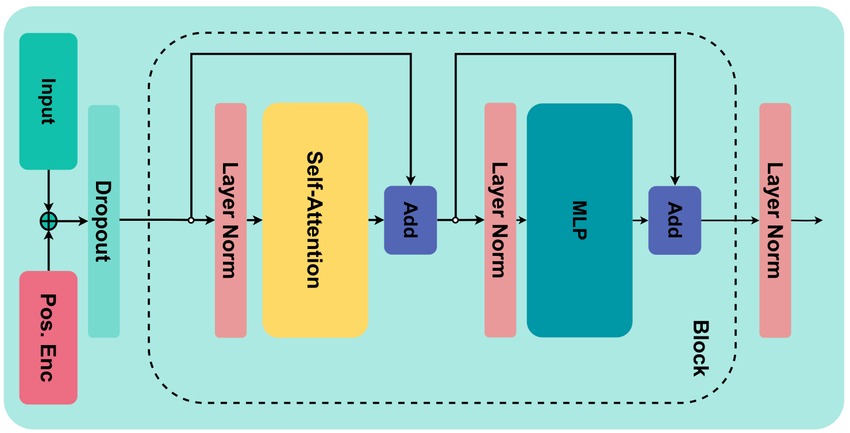

## Exercise 5: GPT

Write a class `GPT` that derives from `nn.Module` and whose `__init__` method takes arguments `vocab_size, context_size, hidden_size, n_layer, n_head, dropout`. 
The `forward` method should take two arguments `x, y` representing sequences of input and target tokens, respectively, both of which have type `torch.long` and shape ($N$, $T$), and returns logits and loss as a tuple. 
The `GPT` module should feature two `nn.Embedding` layers, one for token embeddings and one for positional embedding, i.e., it should embed the position of the corresponding token within the input sequence. 
The positional embedding is necessary for the Transformer to determine the order of its inputs. 
Add the two embeddings and apply a dropout layer. 
Next, apply `n_layers` layers of `Block`s followed by a `nn.LayerNorm` and a `nn.Linear` (without bias) mapping to an output dimension of `vocab_size`. 
Finally, apply the cross-entropy loss function to the logits. 
To save some parameters, apply weight tying between the token embedding layer and the output layer, i.e., they should use the same weights. 
Initialize all weights using a normal distribution with a mean of zero and a standard deviation of 0.02 (except for the output layers of the `MLP`s use $0.02/\sqrt{2 * \mathtt{n\_layer}}$) and all biases to zero. 
Use the argument `dropout` as intensity for all dropout layers in the network. 

In [5]:
########## YOUR SOLUTION HERE ##########

class GPT(nn.Module):
    
    # vocab_size: alle möglichen tokens
    # context_size: max. sequenzlänge
    # hidden_size: dimensionalität der token embeddings ("mit wie vielen eigenschaften möchte ich meine tokens darstellen")
    # n_layer: wie viele Blöcke stapel ich übereinander
    # n_head: wie viel Attention heads pro block
    # dropout: Dropoutwahrscheinlichkeit 
    def __init__(self, vocab_size, context_size, hidden_size, n_layer, n_head, dropout):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, hidden_size) #Token-Embedding lernt Wortbedeutungen
        self.position_embedding = nn.Embedding(context_size, hidden_size)# Positions-Embedding lernt Positionsinformationen (welches Token steht wo)
        self.dropout = nn.Dropout(dropout)

        # nn.ModuleList([...]) speichert mehrere Module in einer Liste
        # Jeder Block ist ein Transformer-Block (Attention + MLP)
        # Wir erzeugen n_layer davon — so viele, wie das Modell tief sein soll
        self.blocks = nn.ModuleList([Block(hidden_size, n_head, dropout) for _ in range(n_layer)]) 
        self.ln_f = nn.LayerNorm(hidden_size)
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.token_embedding.weight  # weight tying

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if module.out_features == module.in_features // 4:  # Heuristik für MLP
                std = 0.02 / math.sqrt(2 * n_layer)
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x, y=None):
        N, T = x.shape
        assert T <= self.position_embedding.num_embeddings, "Sequence too long"

        token_emb = self.token_embedding(x)   # (N, T, D) --> wandelt Token-IDs in Vektoren
        pos = torch.arange(T, device=x.device).unsqueeze(0) # (1, T) --> erstellt Positionen [0, 1, 2, ..., T-1] (unsqueeze: fügt Batch-Dimension hinzu)
        pos_emb = self.position_embedding(pos) # (1, T, D) Positions-Vektoren
        x = self.dropout(token_emb + pos_emb) # (N, T, D) Token + Positionsinformation

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.head(x) # (N, T, vocab_size)

        loss = None
        if y is not None:
            # logits.size(-1) = vocab_size
            # view(-1, vocab_size) formt (N, T, vocab_size) -->  (N*T, vocab_size) --> BSP (2, 4, 100: (8, 100) --> 8 Vorhersagen (eine pro Token), je 100 mögliche Wortklassen
            # y hat Form (N, T) --> wird zu (N*T) enthält einfach alle Ziel-Tokens als lange Liste
            # ignore_index=-1 Sagt der Loss-Funktion: „Ignoriere alle Zielwerte, die -1 sind“
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), ignore_index=-1)
        return logits, loss
    

vocab_size = 100
context_size = 16
hidden_size = 32
n_layer = 2
n_head = 4
dropout = 0.1

model = GPT(vocab_size, context_size, hidden_size, n_layer, n_head, dropout)
x = torch.randint(0, vocab_size, (2, 10))  # 2 Sätze, je 10 Tokens
y = torch.randint(0, vocab_size, (2, 10))

logits, loss = model(x, y)
print("Logits-Form:", logits.shape)
print("Loss:", loss)

Logits-Form: torch.Size([2, 10, 100])
Loss: tensor(4.6261, grad_fn=<NllLossBackward0>)


## Exercise 6: Optimizer

Add a method `configure_optimizers` to the class `GPT` that takes arguments `weight_decay, learning_rate, betas`. 
Divide the model parameters into two groups. 
The first group consists of all parameters with at least 2 dimensions, e.g., weight/embedding matrices and uses a decay of `weight_decay`. 
The second group consists of all other parameters, e.g., biases and layer norms, and does not use weight decay.
Construct and return a `torch.optim.AdamW` optimizer with `learning_rate` and `betas` that operates on these two parameter groups. 

In [6]:
########## YOUR SOLUTION HERE ##########

########## YOUR SOLUTION HERE ##########

class GPT(nn.Module):
    
    def __init__(self, vocab_size, context_size, hidden_size, n_layer, n_head, dropout):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, hidden_size) 
        self.position_embedding = nn.Embedding(context_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(hidden_size, n_head, dropout) for _ in range(n_layer)]) 
        self.ln_f = nn.LayerNorm(hidden_size)
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.token_embedding.weight  

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if module.out_features == module.in_features // 4:  
                std = 0.02 / math.sqrt(2 * n_layer)
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x, y=None):
        N, T = x.shape
        assert T <= self.position_embedding.num_embeddings, "Sequence too long"

        token_emb = self.token_embedding(x) 
        pos = torch.arange(T, device=x.device).unsqueeze(0) 
        pos_emb = self.position_embedding(pos) 
        x = self.dropout(token_emb + pos_emb) 

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if y is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), ignore_index=-1)
        return logits, loss
    
    def configure_optimizers(self, weight_decay, learning_rate, betas):
        decay_params = [] # Gewichtsmatrizen, die Weight Decay bekommen
        no_decay_params = [] # Biases, LayerNorm- und Embedding-Parameter (ohne Decay)

        for name, param in self.named_parameters(): # self.named_parameters() gibt (name, param)-Paare zurück.

            if not param.requires_grad: # nur trainierbare Parameter berücksichtigen.
                continue  # überspringe eingefrorene Parameter
            if param.ndim >= 2: # param.ndim = Anzahl der Dimensionen
                decay_params.append(param)
            else:
                no_decay_params.append(param)

        optimizer = torch.optim.AdamW([
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': no_decay_params, 'weight_decay': 0.0},
        ], lr=learning_rate, betas=betas)

        return optimizer


vocab_size = 100
context_size = 16
hidden_size = 32
n_layer = 2
n_head = 4
dropout = 0.1

model = GPT(vocab_size, context_size, hidden_size, n_layer, n_head, dropout)

optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=3e-4, betas=(0.9, 0.95))

print(optimizer)


AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.1

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.0
)


## Exercise 7: Training

In the code cell below you find some globals, helper functions, and boilerplate code. Extend the given code by a training loop that 
* stops after `max_iters` iterations
* applies the learning rate schedule implemented in `get_lr`
* applies gradient clipping at `grad_clip` using `torch.nn.utils.clip_grad_norm_`
* accumulates gradients for `gradient_accumulation_steps` batches before each weight update
* logs the training loss and learning rate every `log_interval` iterations
* evaluates (and potentially checkpoints) the model using `estimate_loss` every `eval_iters` iterations.

The provided hyperparameter values should be a good guess for training a tiny model on CPU but feel free to experiment with them as you please. In particular, if you have a GPU available, you can try to scale things up a bit. 

In [8]:
eval_interval = 250 # validate model every .. iterations
log_interval = 10 # log training loss every .. iterations
eval_iters = 20 # number of batches for loss estimation
gradient_accumulation_steps = 5 * 8 # used to simulate larger training batch sizes
batch_size = 12 # if gradient_accumulation_steps > 1, this is the micro-batch size
context_size = 64 # sequence length
vocab = 'abcdefghijklmnopqrstuvwxyz0123456789 .!?' # vocabulary
vocab_size = len(vocab) # 40
n_layer = 4 # number of layers
n_head = 4 # number of attention heads
hidden_size = 128 # layer size
dropout = 0.0 # for pretraining 0 is good, for finetuning try 0.1+
learning_rate = 1e-3 # max learning rate
max_iters = 2000 # total number of training iterations
weight_decay = 1e-1
beta1 = 0.9 # for AdamW
beta2 = 0.99 # for AdamW
grad_clip = 1.0 # clip gradients at this value, or disable with 0.0
warmup_iters = 100 # how many steps to warm up for
min_lr = 1e-4 # minimum learning rate, usually ~= learning_rate/10

# learning rate decay scheduler (cosine with warmup)
def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    # 2) if it > max_iters, return min learning rate
    if it > max_iters:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_iters) / (max_iters - warmup_iters)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff ranges 0..1
    return min_lr + coeff * (learning_rate - min_lr)

def load_data(split):
    import re
    
    with open(f'trump_{split}.txt', 'r') as f:
        text = f.read()
    
    text = text.lower() # convert to lower case
    text = re.sub('[^a-z0-9 .!?]', ' ', text) # replace all unknown chars with ' '
    text = re.sub(' +', ' ', text) # reduce multiple blanks to one
    text = [vocab.index(t) for t in text]
    text = torch.tensor(text, dtype=torch.long)
    return text
    
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - context_size, (batch_size,))
    x = torch.stack([data[i:i+context_size] for i in ix])
    y = torch.stack([data[i+1:i+1+context_size] for i in ix])
    return x, y

# helps estimate an arbitrarily accurate loss over either split using many batches
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# data, model, optimizer, etc. 
train_data = load_data('train')
val_data = load_data('val')
model = GPT(vocab_size, context_size, hidden_size, n_layer, n_head, dropout)
optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2))
iter_num = 0
best_val_loss = 1e9
X, Y = get_batch('train') # fetch the very first batch
t0 = time.time()

########## YOUR SOLUTION HERE ##########

## Exercise 8: Inference

Add a method `generate` to the class `GPT` that takes arguments `x, max_new_tokens, temperature=1.0`. 
The method should take a batch of token sequences `x`, which it should extend by `max_new_tokens` new tokens generated by the model. 
Once you have computed the logits for the next token, divide them by `temperature` before applying the softmax. 
After applying the softmax, sample the next token from the resulting categorical distribution. 
Try out different values for `temperature` and compare the results to those from the previous assignment. 

In [ ]:
########## YOUR SOLUTION HERE ##########